## 0. Introduction

The aim of this lab is to get familiar with **Neural Networks**. We will be using some code extracts that were implemented on the week 4 Classification I lab and build a Neural Network.

1.   This lab is the third course-work activity **Assignment 1 Part 3: Neural Networks**
2. Assignment 1 is split into 3 parts: Part 1 - Regression (Lab 3), and Part 2 - Classification (Lab 4) and Part 3 - Neural Networks (Lab 6). The three parts need to be submitted together by  **Monday, 11th November 2024, 10:00am**
3. All questions need to be completed and are assessed.
4. For each lab, a report answering the <font color = 'red'>**questions in red**</font> should be included along with the completed Notebook (.ipynb)
5. The report should be a separate file in **pdf format** (so **NOT** *doc, docx, notebook* etc.).
6. Make sure that **any figures or code** you comment on, are **included in the report**.
7. There are three parts of Assignment 1, therefore you should submit a zip file that contains 1 x Notebook and 1 x PDF for each part. In total: 3 x Notebooks and 3 x PDFs in the submission zip. Make sure the file is well identified with your name, student number, assignment number (for instance, Assignment 1), module code.
8. No other means of submission other than the appropriate QM+ link is acceptable at any time (so NO email attachments, etc.)
9. **PLAGIARISM** <ins>is an irreversible non-negotiable failure in the course</ins> (if in doubt of what constitutes plagiarism, ask!).


For this lab, we will be using the [iris dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#iris-dataset).

## 0.1 Intro to Neural Networks

As covered in the lecture notes, Neural Networks (NN) are inspired by biological brains. Each "neuron" does a very simple calculation, however collectively they can do powerful computations.

A simple model neuron is called a Perceptron and is comprised of three components:
1. The weights
2. The input function
3. The activation function

perceptron.png

We can re-imagine the logistic regression unit as a neuron (function) that multiplies the input by the parameters (weights) and squashes the resulting sum through the sigmoid.

A Feed Forward NN will be a connected set of logistic regression units, arranged in layers. Each unit’s output is a non-linear function (e.g., sigmoid, step function) of a linear combination of its inputs.
nn.svg

We will use the sigmoid as an activation function. Add the sigmoid function and `LogisticRegression` class from week 4 lab below.
Change the parameter initialization in `LogisticRegression`, so that a random set of initial weights is used.



<u><font color="red">**Q1.** Why is it important to use a random set of initial weights rather than initializing all weights as zero in a Neural Network? [2 marks] </font></u>


In [24]:
import torch
from torch import nn
from torch import optim
from torch.nn import functional as F
from sklearn import model_selection
from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from IPython import display

import typing
%matplotlib inline

torch.manual_seed(0)

In [25]:
## sigmoid
def sigmoid(z: torch.Tensor) -> torch.Tensor:
  return 1 / (1 + torch.exp(-z))



In [26]:
## logistic regression class
class LogisticRegression(nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(1, num_features) * 0.1, requires_grad=True)

    def forward(self, x):
        z = torch.matmul(x, self.weight.T)
        y = torch.sigmoid(z)
        return y


# 1. The XOR problem

Let's revisit the XOR problem.

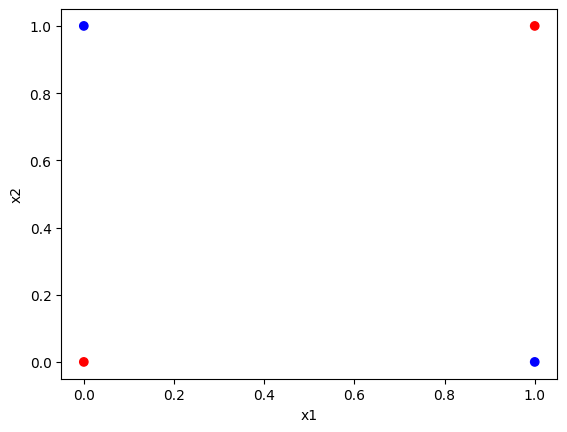

In [27]:
x1 = [0, 0, 1, 1]
x2 = [0, 1, 0, 1]
y = [0, 1, 1, 0]

c_map = ['r', 'b', 'b', 'r']
plt.scatter(x1, x2, c=c_map)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

<u><font color="red"> **Q2.** How does a NN solve the XOR problem? [1 marks]</font></u>


We will implement back-propagation on a Feed Forward network to solve the XOR problem. The nework will have 2 inputs, 2 hidden neurons and one output neuron. The architecture is visualised as follows:

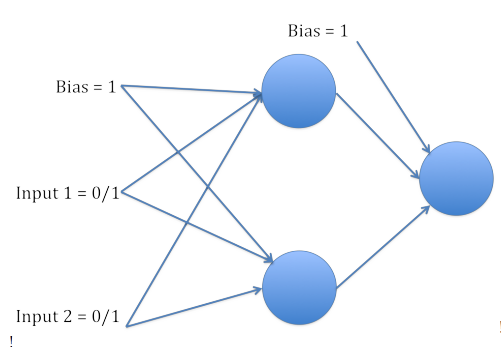

Using `LogisticRegression` and `sigmoid` from week 4 lab, implement the forward pass in the class below. Assume a single sample at a time (i.e. the shape of `x` is `(1, num_features`)). [2 marks]

Hint: Check `ModuleList` [documentation](https://pytorch.org/docs/stable/generated/torch.nn.ModuleList.html).

In [28]:
class NeuralNetwork(nn.Module):
    def __init__(self, num_inputs, num_neurons, num_outputs):
        super().__init__()
        self.hidden_layer = nn.ModuleList([LogisticRegression(num_inputs) for i in range(num_neurons)])
        self.output_layer = nn.ModuleList([LogisticRegression(num_neurons+1) for i in range(num_outputs)]) # +1 for the bias

    def forward(self, x: torch.tensor) -> torch.tensor:
        y_hidden = torch.ones(len(self.hidden_layer) + 1) # +1 for the bias
        ### your code here
        # Computing the hidden layer outputs, then reshaping to add batch diementions, initializing the output layer, and computing output of output
        for i, neuron in enumerate(self.hidden_layer):
            y_hidden[i] = neuron.forward(x)
        y_hidden = y_hidden.unsqueeze(0)
        y = torch.zeros(1, len(self.output_layer))
        for i, neuron in enumerate(self.output_layer):
            y[0, i] = neuron.forward(y_hidden)
        return y

    def backward_pass(self, x: torch.tensor, y: torch.tensor, lr: float) -> None:
        ### your code here
        # Ensure x and y are 2D tensors
        if x.dim() == 1:
            x = x.unsqueeze(0)
        if y.dim() == 1:
            y = y.unsqueeze(0)

        # Getting predictions from forward pass, using the MSE, Zero out gradient in hidden layer and previous gradients
        y_pred = self.forward(x)

        # 𝛿𝑘=(𝑦𝑘−𝑡𝑘)×𝑔′(𝑥𝑘) formula for outputs, find g'(xk) this is g(x) x (1 - g(xk)) this is y_pred x (1 - y_pred)
        # (𝑦𝑘−𝑡𝑘) = (y_pred - y)
        output_gradient = (y_pred - y)  # E(w) = sum(y - yi)^2

        hidden_output = torch.ones(len(self.hidden_layer) + 1)  # +1 for bias term
        for i, neuron in enumerate(self.hidden_layer):
            hidden_output[i] = neuron.forward(x)  # sigmoid activation

        hidden_gradient = torch.zeros(len(self.hidden_layer))
        for j in range(len(self.hidden_layer)):
            error = 0
            for k in range(len(self.output_layer)):
                # Get weight from hidden neuron j to output neuron k
                weight_j = self.output_layer[k].weight[0, j]
                # error = Wjk x 𝛿𝑘
                error += weight_j * output_gradient[0, k]
            # 𝛿𝑗=𝑔′(𝑥𝑗) x ∑𝑘𝑤𝑗𝑘𝛿𝑘, g'(x) is the hidden_output[j] x  (1 - hidden_output[j])
            hidden_gradient[j] = hidden_output[j] * (1 - hidden_output[j]) * error

        # Update output weights
        with torch.no_grad():
            for k, neuron in enumerate(self.output_layer):
                for j in range(neuron.weight.shape[1]):
                    # activation from hidden neuron output/ bias if it's less
                    activation = hidden_output[j]  # Works for both hidden neurons and bias
                    # Wjk = Wjk - n x 𝛿𝑘 x aj
                    neuron.weight[0, j] -= lr * output_gradient[0, k] * activation

        # Update hidden weights
        with torch.no_grad():
            for j, neuron in enumerate(self.hidden_layer):
                for i in range(neuron.weight.shape[1] - 1):  # -1 to exclude bias
                    # Wij = Wij - n x 𝛿𝑗 x xi
                    neuron.weight[0, i] -= lr * hidden_gradient[j] * x[0, i]

                # Update bias weight (last weight, input = 1)
                neuron.weight[0, -1] -= lr * hidden_gradient[j] * 1.0

        return

In [29]:
# test it works!!
x_test = torch.tensor([0., 0., 1.]) # last value is the bias
y_test = torch.tensor([0.])
model = NeuralNetwork(num_inputs=3, num_neurons=2, num_outputs=1)
print(model(x_test))
print(model)
for name, param in model.named_parameters():
  print(name, param)

print('\nHidden layer weight matrix:')
print(torch.stack(list(model.hidden_layer.parameters())))

tensor([[0.4963]], grad_fn=<CopySlices>)
NeuralNetwork(
  (hidden_layer): ModuleList(
    (0-1): 2 x LogisticRegression()
  )
  (output_layer): ModuleList(
    (0): LogisticRegression()
  )
)
hidden_layer.0.weight Parameter containing:
tensor([[ 0.1541, -0.0293, -0.2179]], requires_grad=True)
hidden_layer.1.weight Parameter containing:
tensor([[ 0.0568, -0.1085, -0.1399]], requires_grad=True)
output_layer.0.weight Parameter containing:
tensor([[ 0.0403,  0.0838, -0.0719]], requires_grad=True)

Hidden layer weight matrix:
tensor([[[ 0.1541, -0.0293, -0.2179]],

        [[ 0.0568, -0.1085, -0.1399]]], grad_fn=<StackBackward0>)


In the `NeuralNetwork` class above, fill in the `backward_pass()` method.

The implementation should support outputs of any size. To implement the backward pass, follow the steps below:



*   **Step 1:** For each output, $k$, calculate the partial derivative: $\delta_{k} = (y_{k}-t_{k}) \times g'(x_{k})$ \\
where $y_{k}$ is the response of the output neuron and $t_{k}$ is the desired output (target). The derivative of the sigmoid function $g'(x_{k})$ is defined as $g'(x_{k}) = g(x_{k}) × (1 - g(x_{k}))$ [1 marks]
*  **Step 2:** We now need to propagate this error to the hidden neurons. To accomplish this remember that: $$
 \delta_{j} = g^\prime(x_{j}) \sum_{k} w_{jk} \delta_{k}
$$  where $\delta_{j}$ is the error on the j-th hidden neuron,$x_{j}$ is the value of the hidden neuron (before it has been passed through the sigmoid function), $g^\prime$ is the derivative of the sigmoid function, $\delta_{k}$ is the error from the output neuron calculated in step 1, and $w_{jk}$ is the weight from the hidden neuron $j$ to the output neuron $k$. [1 marks]

* **Step 3:** We now need to update the output weights, i.e. the connections from the hidden neurons to the output neurons. This is accomplished using the formula: $$
 w_{jk} = w_{jk} - \eta \delta_{k} \alpha_{j}
$$ where $w_{jk}$ is the weight connecting the j-th hidden neuron to the k-th output neuron. $\alpha_{j}$ is the activity of the j-th hidden neuron (after it has been transformed by the sigmoid function), $\delta_{k}$ is the error from the output neuron stored in output\_deltas and $\eta$ is the learning rate [1 mark]

* **Step 4:**  Finally we need to update the hidden weights, i.e. the connections from the hidden neurons to the inputs. Here, again we use this equation $$
 w_{ij} = w_{ij} - \eta \delta_{j} x_{i}
$$ where $w_{ij}$ is the weight connecting the i-th input to the j-th hidden neuron. $x_{i}$ is the i-th input, $\delta_{j}$ is the backpropagated error (i.e., hidden deltas) from the j-th hidden neuron and $\eta$ is the learning rate. [1 mark]



In [30]:
# test it works
model.backward_pass(x_test, y_test, 1)

Now modify the code below to train a model on the XOR problem. Make sure to use an appropriate lr and number of iterations. Use the BCE method from week 4 to visualize cost. [1 mark]

torch.Size([4, 3])


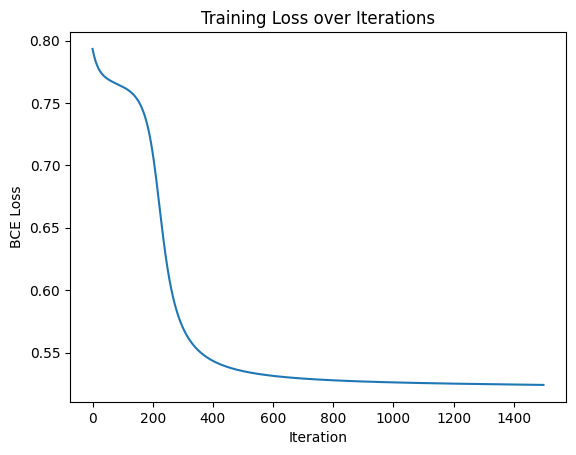


Final Loss: 0.524039
Accuracy: 75% (3/4 correct)


In [31]:
def bce(y_true, y_pred):
    #BCE = [y*log(y_pred) + (1-y)*log(1-y_pred)]
    epsilon = 1e-15
    y_pred = torch.clamp(y_pred, epsilon, 1-epsilon)
    loss = -(y_true*torch.log(y_pred) + (1-y_true)*torch.log(1-y_pred))
    return loss.mean()

x1 = torch.tensor([0., 0., 1., 1.])
x2 = torch.tensor([0., 1., 0., 1.])
bias = torch.ones_like(x1)
x = torch.stack([x1, x2, bias]).permute(1, 0)
print(x.shape)

y = torch.tensor([0., 1., 1., 0.])

lr = 0.5
iterations = 1500

model = NeuralNetwork(num_inputs=3, num_neurons=2, num_outputs=1)

errors = list()
for ep in range(iterations):
    error = 0
    for i in range(x.shape[0]):
        y_pred = model(x[i])
        error += bce(y[i], y_pred)
        model.backward_pass(x[i], y[i], lr)
    errors.append(error.item()/x.shape[0])

plt.plot(list(range(iterations)), errors)
plt.xlabel('Iteration')
plt.ylabel('BCE Loss')
plt.title('Training Loss over Iterations')
plt.show()

y_pred = torch.zeros_like(y)
for i in range(x.shape[0]):
    y_pred[i] = model(x[i])


predictions_binary = (y_pred > 0.5).float()
correct = (predictions_binary == y).sum().item()
accuracy = correct / len(y) * 100

print(f"\nFinal Loss: {errors[-1]:.6f}")
print(f"Accuracy: {accuracy:.0f}% ({correct}/{len(y)} correct)")

#debugging
#if accuracy == 100:
    #print("\neural network has learned XOR")


# 2. Iris Dataset
We will now use pytorch built-in methods to create an MLP classifier for the iris dataset.

In [32]:
iris = datasets.load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

Split the data to train and test sets (make sure the same random seed is used as previously) and normalize using the method from week 4. We will use all attributes in this lab. [2 marks]

In [33]:
### your code here
# Spliting the data into train and test sets usual 0.2, same random seed as before.
X_train, X_test, y_train, y_test = model_selection.train_test_split(iris.data, iris.target, test_size=0.2, random_state=0)

# Normalize the data (standardization: mean=0, std=1, calculating the mean and std from training data only
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

# Normalize train and test sets using training statistics
X_train_normalized = (X_train - mean) / std
X_test_normalized = (X_test - mean) / std

# Convert to PyTorch tensors
X_train = torch.tensor(X_train_normalized, dtype=torch.float32)
X_test = torch.tensor(X_test_normalized, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# Verify shapes
print(f"\nTrain set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Train labels shape: {y_train.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"\nNumber of features: {X_train.shape[1]}")
print(f"Number of classes: {len(torch.unique(y_train))}")


Train set shape: torch.Size([120, 4])
Test set shape: torch.Size([30, 4])
Train labels shape: torch.Size([120])
Test labels shape: torch.Size([30])

Number of features: 4
Number of classes: 3


Using pytorch built in methods (and using the training loop from week 4 as guideline for the train loop), build an MLP with one hidden layer. Train the network multiple times for the following number of hidden neurons `{1, 2, 4, 8, 16, 32}`.

<u><font color="red"> **Q3.** Explain the performance of the different networks on the training and test sets. How does it compare to the logistic regression example? Make sure that the data you are refering to is clearly presented and appropriately labeled in the report. [8 marks]</font></u>

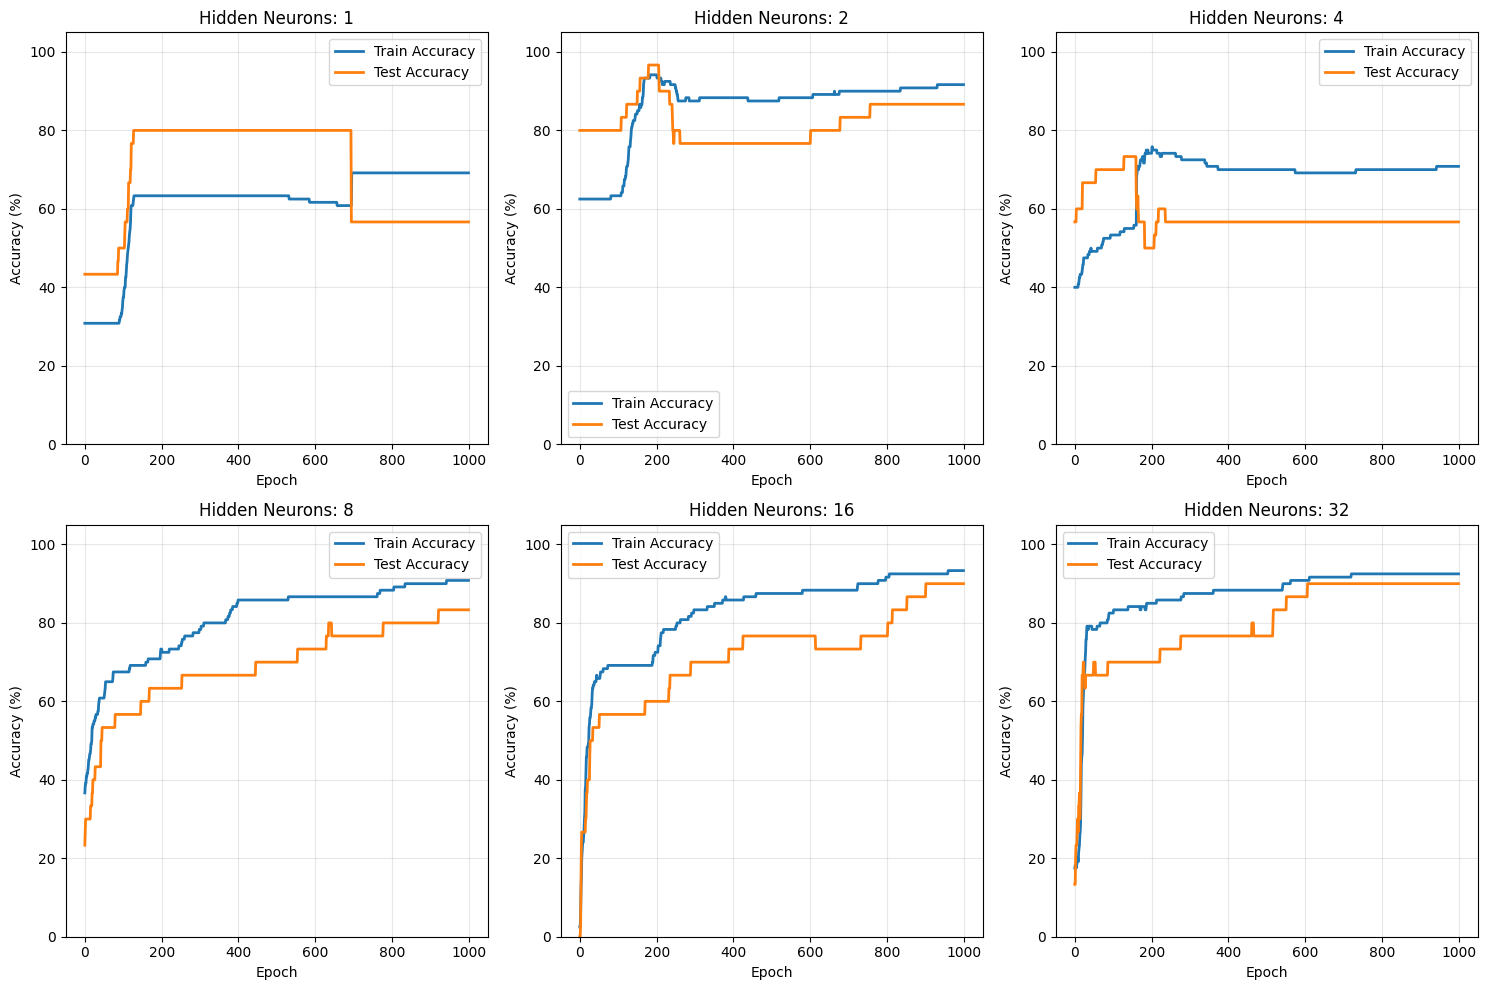

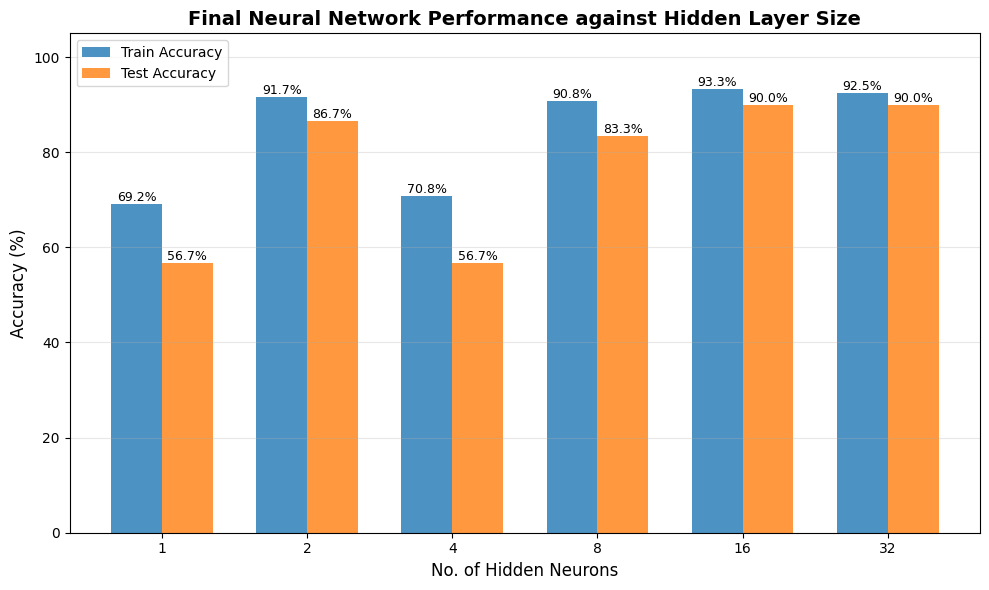

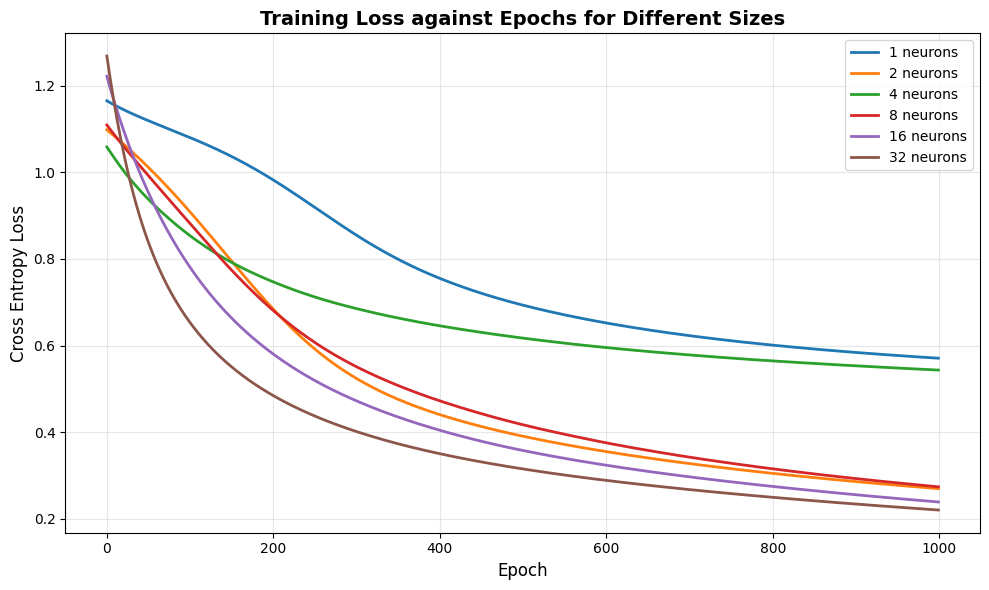

Neural Network Performance with different sizes
Hidden Neurons     Final Train Acc    Final Test Acc     Gap (Train-Test)  
1                            69.17%            56.67%            12.50%
2                            91.67%            86.67%             5.00%
4                            70.83%            56.67%            14.17%
8                            90.83%            83.33%             7.50%
16                           93.33%            90.00%             3.33%
32                           92.50%            90.00%             2.50%
Overfitting Description
  1 neurons: Train= 69.17%, Test= 56.67%, Gap=12.50% - Overfitting
  2 neurons: Train= 91.67%, Test= 86.67%, Gap= 5.00% - Good Generalization
  4 neurons: Train= 70.83%, Test= 56.67%, Gap=14.17% - Overfitting
  8 neurons: Train= 90.83%, Test= 83.33%, Gap= 7.50% - Slight Overfitting
 16 neurons: Train= 93.33%, Test= 90.00%, Gap= 3.33% - Good Generalization
 32 neurons: Train= 92.50%, Test= 90.00%, Gap= 2.50% - Good Ge

In [34]:
### your code here
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MLP, self).__init__()
        # First layer input this is hidden
        self.fl1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()  # Non-linear activation
        # Second layer also hidden
        self.fl2 = nn.Linear(hidden_size, num_classes)
    #this is the output scores, defining how the data will move through the network
    def forward(self, x):
        out = self.fl1(x)
        out = self.relu(out)
        out = self.fl2(out)
        return out
def train_mlp(model, X_train, y_train, X_test, y_test, num_epochs=1000, learning_rate=0.01):
    #Training the MLP and tracking training/test accuracy over epochs
    #The loss fuction and how the parameters are updated
    cel = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    train_accuracies = []
    test_accuracies = []
    train_losses = []
    #The training loop this includes the forward and backward pass, computing the loss and gradient and updating weights
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = cel(outputs, y_train)
        loss.backward()
        optimizer.step()

        # Calculating the training accuracy
        _, predicted_train = torch.max(outputs.data, 1)
        train_acc = (predicted_train == y_train).sum().item() / len(y_train) * 100

        # Calculating the training accuracy for test set
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            _, predicted_test = torch.max(test_outputs.data, 1)
            test_acc = (predicted_test == y_test).sum().item() / len(y_test) * 100

        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        train_losses.append(loss.item())



    return train_accuracies, test_accuracies, train_losses

    # Configuing the model size to test and store results
input_size = X_train.shape[1]
num_classes = len(torch.unique(y_train))
hidden_sizes = [1, 2, 4, 8, 16, 32] #The given numbers of hidden neurons
num_epochs = 1000
learning_rate = 0.01

results = {}
#Printing the progress to see what is happening during the training with different layer sizes
#print("Training the MLP layers with the different sizes")

#Training 6 seperate networks with different hidden layers
for hidden_size in hidden_sizes:
    #print(f"Training MLP with {hidden_size} hidden neurons")
    torch.manual_seed(0)
    model = MLP(input_size, hidden_size, num_classes)

    # Main training model section
    train_acc, test_acc, train_loss = train_mlp(
        model, X_train, y_train, X_test, y_test,
        num_epochs=num_epochs, learning_rate=learning_rate
    )

    results[hidden_size] = {'model': model,'train_acc': train_acc,'test_acc': test_acc,'train_loss': train_loss,'final_train_acc': train_acc[-1],'final_test_acc': test_acc[-1],
      'final_loss': train_loss[-1]}

    #Used for debugging
    #print(f"\nResults for {hidden_size} hidden neurons:")
    #print(f"  Training Accuracy: {train_acc[-1]:.2f}%")
    #print(f"  Test Accuracy: {test_acc[-1]:.2f}%")
    #print(f"  Loss: {train_loss[-1]:.4f}")


# line graphs Plots to show if the training accuracy is changing over time, to understand if the model is learning,
#the training against the test accuracy over the epochs for each hidden layer size, to understand which ones overfit and generalise well

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, hidden_size in enumerate(hidden_sizes):
    ax = axes[idx]
    train_acc = results[hidden_size]['train_acc']
    test_acc = results[hidden_size]['test_acc']

    ax.plot(train_acc, label='Train Accuracy', linewidth=2)
    ax.plot(test_acc, label='Test Accuracy', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'Hidden Neurons: {hidden_size}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 105])

plt.tight_layout()
plt.show()

# Bar charts to show the final accuracy numbers, final training and test accuracy
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(hidden_sizes))
width = 0.35

train_f = [results[h]['final_train_acc'] for h in hidden_sizes]
test_f = [results[h]['final_test_acc'] for h in hidden_sizes]

train_bars = ax.bar(x - width/2, train_f, width, label='Train Accuracy', alpha=0.8)
test_bars = ax.bar(x + width/2, test_f, width, label='Test Accuracy', alpha=0.8)

ax.set_xlabel('No. of Hidden Neurons', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Final Neural Network Performance against Hidden Layer Size', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(hidden_sizes)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 105])


for bars in [train_bars, test_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Line graph to show how the cross entropy is going down during training to see models error decreases while training
fig, ax = plt.subplots(figsize=(10, 6))

for hidden_size in hidden_sizes:
    train_loss = results[hidden_size]['train_loss']
    ax.plot(train_loss, label=f'{hidden_size} neurons', linewidth=2)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Cross Entropy Loss', fontsize=12)
ax.set_title('Training Loss against Epochs for Different Sizes', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("Neural Network Performance with different sizes")
print(f"{'Hidden Neurons':<18} {'Final Train Acc':<18} {'Final Test Acc':<18} {'Gap (Train-Test)':<18}")

for hidden_size in hidden_sizes:
    train_acc = results[hidden_size]['final_train_acc']
    test_acc = results[hidden_size]['final_test_acc']
    gap = train_acc - test_acc
    print(f"{hidden_size:<18} {train_acc:>15.2f}%  {test_acc:>15.2f}%  {gap:>15.2f}%")

print("Overfitting Description")
for hidden_size in hidden_sizes:
    train_acc = results[hidden_size]['final_train_acc']
    test_acc = results[hidden_size]['final_test_acc']
    gap = train_acc - test_acc

    if gap > 10:
        status = "Overfitting"
    elif gap > 5:
        status = "Slight Overfitting"
    else:
        status = "Good Generalization"

    print(f"{hidden_size:>3} neurons: Train={train_acc:>6.2f}%, Test={test_acc:>6.2f}%, Gap={gap:>5.2f}% - {status}")



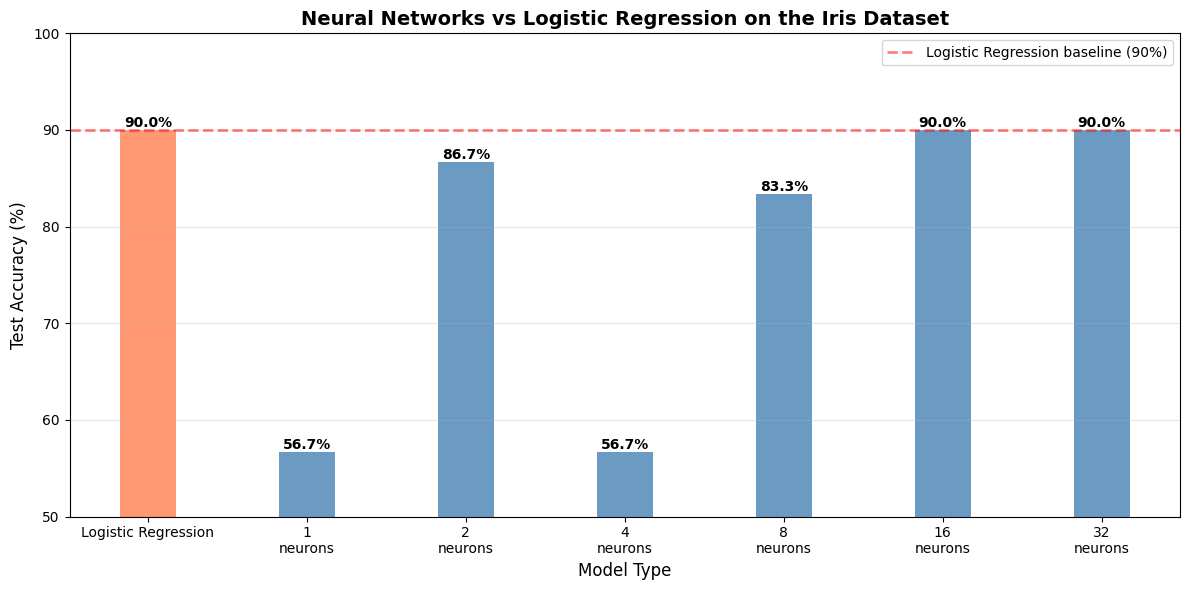

In [35]:


# Week 4 Logistic Regression Results
week4_logr_test_acc = 90.00   # From Week 4 Q8 (with softmax)
week4_logr_params = 12        # 4 features × 3 classifiers, bias=False
week4_correct = 27              # 27 out of 30 correct
week4_total = 30



fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(hidden_sizes) + 1)
width = 0.35

# MLP results from the training
test_final = [results[h]['final_test_acc'] for h in hidden_sizes]

# Include Week 4 logistic regression
all_models = ['Logistic Regression'] + [f'{h}\nneurons' for h in hidden_sizes]
test_accs = [week4_logr_test_acc] + test_final

bars = ax.bar(x, test_accs, width, alpha=0.8, color=['coral'] + ['steelblue']*len(hidden_sizes))

ax.set_xlabel('Model Type', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Neural Networks vs Logistic Regression on the Iris Dataset', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(all_models)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([50, 100])

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# dotted line at 90% to clearly see the logistic regression against NN bigger networks
ax.axhline(y=90, color='red', linestyle='--', linewidth=2, alpha=0.5,
           label='Logistic Regression baseline (90%)')
ax.legend()

plt.tight_layout()
plt.show()



